<a href="https://colab.research.google.com/github/adanzee/GradCam-Model/blob/main/GradCam_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jessicali9530/lfw-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Path to dataset files: /kaggle/input/lfw-dataset


In [ ]:
# ── 0. DATASET PATH ──
DATASET_ROOT = "/content/drive/MyDrive/lfw-deepfunneled"
print('data done')


import os, sys, random, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle
import seaborn as sns

from PIL import Image as PImage
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)


class CFG:
    # ── data
    min_images_per_class = 20          # drop identities with fewer images
    img_size             = 64          # resize to 64×64
    # ── training
    batch_size   = 32
    num_epochs   = 30
    lr           = 1e-3
    weight_decay = 1e-4
    train_ratio  = 0.70
    val_ratio    = 0.15
    # (test = 1 - train - val)
    # ── reproducibility
    seed = 42
    # ── output
    out_dir = Path("outputs")


CFG.out_dir.mkdir(exist_ok=True)

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(s)

set_seed(CFG.seed)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n{'='*60}")
print(f"  Device : {DEVICE}")
print(f"  PyTorch: {torch.__version__}")
print(f"{'='*60}\n")

#loading the dataset
def locate_lfw_root(base: str) -> Path:
    """
    Walk a few candidate sub-paths to find the directory that contains
    per-identity sub-folders.
    """
    candidates = [
        Path(base),
        Path(base) / "lfw",
        Path(base) / "lfw" / "lfw",
        Path(base) / "data" / "lfw",
        Path(base) / "lfw_funneled",
        Path(base) / "lfw_home" / "lfw_funneled",
    ]
    for c in candidates:
        if c.is_dir():
            # Check if this 'c' directory directly contains subdirectories that look like identity folders
            # i.e., they are directories and contain some .jpg files
            for potential_identity_dir in c.iterdir():
                if potential_identity_dir.is_dir() and any(potential_identity_dir.glob("*.jpg")):
                    return c # Found the root that contains identity folders
    raise FileNotFoundError(
        f"\n[ERROR] Could not find the LFW identity folders under '{base}'.\n"
        "Please set DATASET_ROOT to the correct path.\n"
        "Expected structure:  <DATASET_ROOT>/<IdentityName>/*.jpg  (after locating the correct subfolder)\n"
    )


class LFWDataset(Dataset):
    """
    Loads LFW images from disk.
    Applies standard augmentation during training.
    """

    TRAIN_TF = transforms.Compose([
        transforms.Resize((CFG.img_size, CFG.img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2,
                               saturation=0.2, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
    ])

    EVAL_TF = transforms.Compose([
        transforms.Resize((CFG.img_size, CFG.img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3),
    ])

    def __init__(self, samples, labels, transform):
        self.samples   = samples      # list of Path objects
        self.labels    = labels       # list of int
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img = PImage.open(self.samples[idx]).convert("RGB")
        return self.transform(img), self.labels[idx]


def build_dataloaders():
    lfw_dir = locate_lfw_root(DATASET_ROOT)
    print(f"[INFO] LFW root found at: {lfw_dir}\n")

    # ── collect paths & filter by minimum samples ──────────────────────
    all_paths, all_labels = [], []
    class_names = []

    for idx, person_dir in enumerate(sorted(lfw_dir.iterdir())):
        if not person_dir.is_dir():
            continue
        imgs = sorted(person_dir.glob("*.jpg"))
        if len(imgs) < CFG.min_images_per_class: # Ensure person_dir is an identity directory (has images)
            continue
        class_names.append(person_dir.name)

    # re-index cleanly
    label_map = {name: i for i, name in enumerate(class_names)}

    for name in class_names:
        person_dir = lfw_dir / name
        for img_path in sorted(person_dir.glob("*.jpg")):
            all_paths.append(img_path)
            all_labels.append(label_map[name])

    n_classes = len(class_names)
    print(f"[INFO] Classes (identities) : {n_classes}")
    print(f"[INFO] Total images          : {len(all_paths)}")

    # ── stratified-ish split ────────────────────────────────────────────
    indices = list(range(len(all_paths)))
    random.shuffle(indices)
    n      = len(indices)
    n_tr   = int(n * CFG.train_ratio)
    n_val  = int(n * CFG.val_ratio)

    tr_idx  = indices[:n_tr]
    val_idx = indices[n_tr:n_tr + n_val]
    te_idx  = indices[n_tr + n_val:]

    def make_ds(idxs, tf):
        return LFWDataset([all_paths[i] for i in idxs],
                          [all_labels[i] for i in idxs], tf)

    train_ds = make_ds(tr_idx,  LFWDataset.TRAIN_TF)
    val_ds   = make_ds(val_idx, LFWDataset.EVAL_TF)
    test_ds  = make_ds(te_idx,  LFWDataset.EVAL_TF)

    print(f"[INFO] Train / Val / Test    : "
          f"{len(train_ds)} / {len(val_ds)} / {len(test_ds)}\n")

    kw = dict(batch_size=CFG.batch_size, num_workers=0, pin_memory=True)
    train_loader = DataLoader(train_ds, shuffle=True,  **kw)
    val_loader   = DataLoader(val_ds,   shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  shuffle=False, **kw)

    return train_loader, val_loader, test_loader, class_names, test_ds

data done

  Device : cuda
  PyTorch: 2.10.0+cu128



In [ ]:
train_loader, val_loader, test_loader, class_names, test_ds = build_dataloaders()

[INFO] LFW root found at: /content/drive/MyDrive/lfw-deepfunneled

[INFO] Classes (identities) : 62
[INFO] Total images          : 3023
[INFO] Train / Val / Test    : 2116 / 453 / 454



In [ ]:
#CNN Layer


class ConvBlock(nn.Module):
    """Conv → BN → ReLU  (optionally with MaxPool)."""

    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),  # Removed inplace=True
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class FaceNet(nn.Module):

    def __init__(self, n_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3,   32,  pool=True),   # → 32×32
            ConvBlock(32,  64,  pool=True),   # → 16×16
            ConvBlock(64,  128, pool=True),   # → 8×8
            ConvBlock(128, 256, pool=True),   # → 4×4
        )
        # last conv layer kept separately for Grad-CAM hook
        self.last_conv = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(),  # Removed inplace=True
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.last_conv(x)
        x = self.gap(x)
        return self.classifier(x)


def print_model_summary(model, n_classes):
    total = sum(p.numel() for p in model.parameters())
    train = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("─" * 50)
    print(f"  Model          : FaceNet")
    print(f"  Classes        : {n_classes}")
    print(f"  Total params   : {total:,}")
    print(f"  Trainable      : {train:,}")
    print("─" * 50 + "\n")


──────────────────────────────────────────────────
  Model          : FaceNet
  Classes        : 10
  Total params   : 1,116,970
  Trainable      : 1,116,970
──────────────────────────────────────────────────



In [ ]:
n_classes = len(class_names)
model = FaceNet(n_classes).to(DEVICE)
print_model_summary(model, n_classes)

──────────────────────────────────────────────────
  Model          : FaceNet
  Classes        : 62
  Total params   : 1,143,646
  Trainable      : 1,143,646
──────────────────────────────────────────────────



In [ ]:
#Training the model
def train_one_epoch(model, loader, criterion, optimiser):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimiser.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimiser.step()
        running_loss += loss.item() * imgs.size(0)
        correct      += (out.argmax(1) == labels).sum().item()
        total        += imgs.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out  = model(imgs)
        loss = criterion(out, labels)
        running_loss += loss.item() * imgs.size(0)
        preds = out.argmax(1)
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return running_loss / total, correct / total, all_preds, all_labels


def train(model, train_loader, val_loader, n_epochs):
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimiser = optim.AdamW(model.parameters(),
                            lr=CFG.lr, weight_decay=CFG.weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=n_epochs)

    history = {"tr_loss": [], "val_loss": [],
               "tr_acc":  [], "val_acc":  []}

    best_val_acc, best_state = 0.0, None

    print(f"{'Epoch':>6}  {'Tr Loss':>8}  {'Tr Acc':>7}  "
          f"{'Val Loss':>9}  {'Val Acc':>8}  {'LR':>10}")
    print("─" * 60)

    for ep in range(1, n_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader,
                                          criterion, optimiser)
        va_loss, va_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        history["tr_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["tr_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        lr_now = scheduler.get_last_lr()[0]
        dt     = time.time() - t0
        print(f"{ep:>6}  {tr_loss:>8.4f}  {tr_acc:>6.2%}  "
              f"{va_loss:>9.4f}  {va_acc:>7.2%}  {lr_now:>10.2e}  "
              f"({dt:.1f}s)")

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state   = {k: v.cpu().clone()
                            for k, v in model.state_dict().items()}

    print(f"\n[INFO] Best Val Accuracy: {best_val_acc:.2%}")
    model.load_state_dict(best_state)
    torch.save(best_state, CFG.out_dir / "best_facenet.pth")
    return history


In [ ]:
history = train(model, train_loader, val_loader, CFG.num_epochs)

 Epoch   Tr Loss   Tr Acc   Val Loss   Val Acc          LR
────────────────────────────────────────────────────────────
     1    3.8727  15.55%     3.5731   21.85%    9.97e-04  (17.3s)
     2    3.5095  19.14%     3.2892   26.05%    9.89e-04  (14.6s)
     3    3.1945  25.24%     3.3340   29.14%    9.76e-04  (13.4s)
     4    2.8942  32.28%     3.1055   33.77%    9.57e-04  (13.3s)
     5    2.6180  40.17%     2.8255   36.87%    9.33e-04  (13.1s)
     6    2.3879  47.40%     2.3354   47.24%    9.05e-04  (13.0s)
     7    2.1556  54.35%     2.2124   50.55%    8.72e-04  (13.1s)
     8    1.9916  60.87%     2.1869   52.98%    8.35e-04  (13.0s)
     9    1.8375  66.78%     2.2840   54.53%    7.94e-04  (13.6s)
    10    1.6953  70.98%     2.0870   57.40%    7.50e-04  (13.4s)
    11    1.5659  76.51%     2.2357   55.19%    7.03e-04  (13.5s)
    12    1.5524  77.36%     1.9399   64.24%    6.55e-04  (13.7s)
    13    1.4073  82.66%     1.8414   67.77%    6.04e-04  (13.0s)
    14    1.3214  85.1

In [ ]:
#Accuracy of the model
def plot_training_curves(history):
    epochs = range(1, len(history["tr_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training Curves – FaceNet on LFW", fontsize=14, fontweight="bold")

    # Loss
    ax = axes[0]
    ax.plot(epochs, history["tr_loss"],  "b-o", ms=4, label="Train Loss")
    ax.plot(epochs, history["val_loss"], "r-o", ms=4, label="Val Loss")
    ax.set_title("Loss"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(alpha=0.3)

    # Accuracy
    ax = axes[1]
    ax.plot(epochs, [a*100 for a in history["tr_acc"]],
            "b-o", ms=4, label="Train Acc")
    ax.plot(epochs, [a*100 for a in history["val_acc"]],
            "r-o", ms=4, label="Val Acc")
    ax.set_title("Accuracy"); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
    ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    path = CFG.out_dir / "training_curves.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"[SAVED] {path}")

[SAVED] outputs/training_curves.png


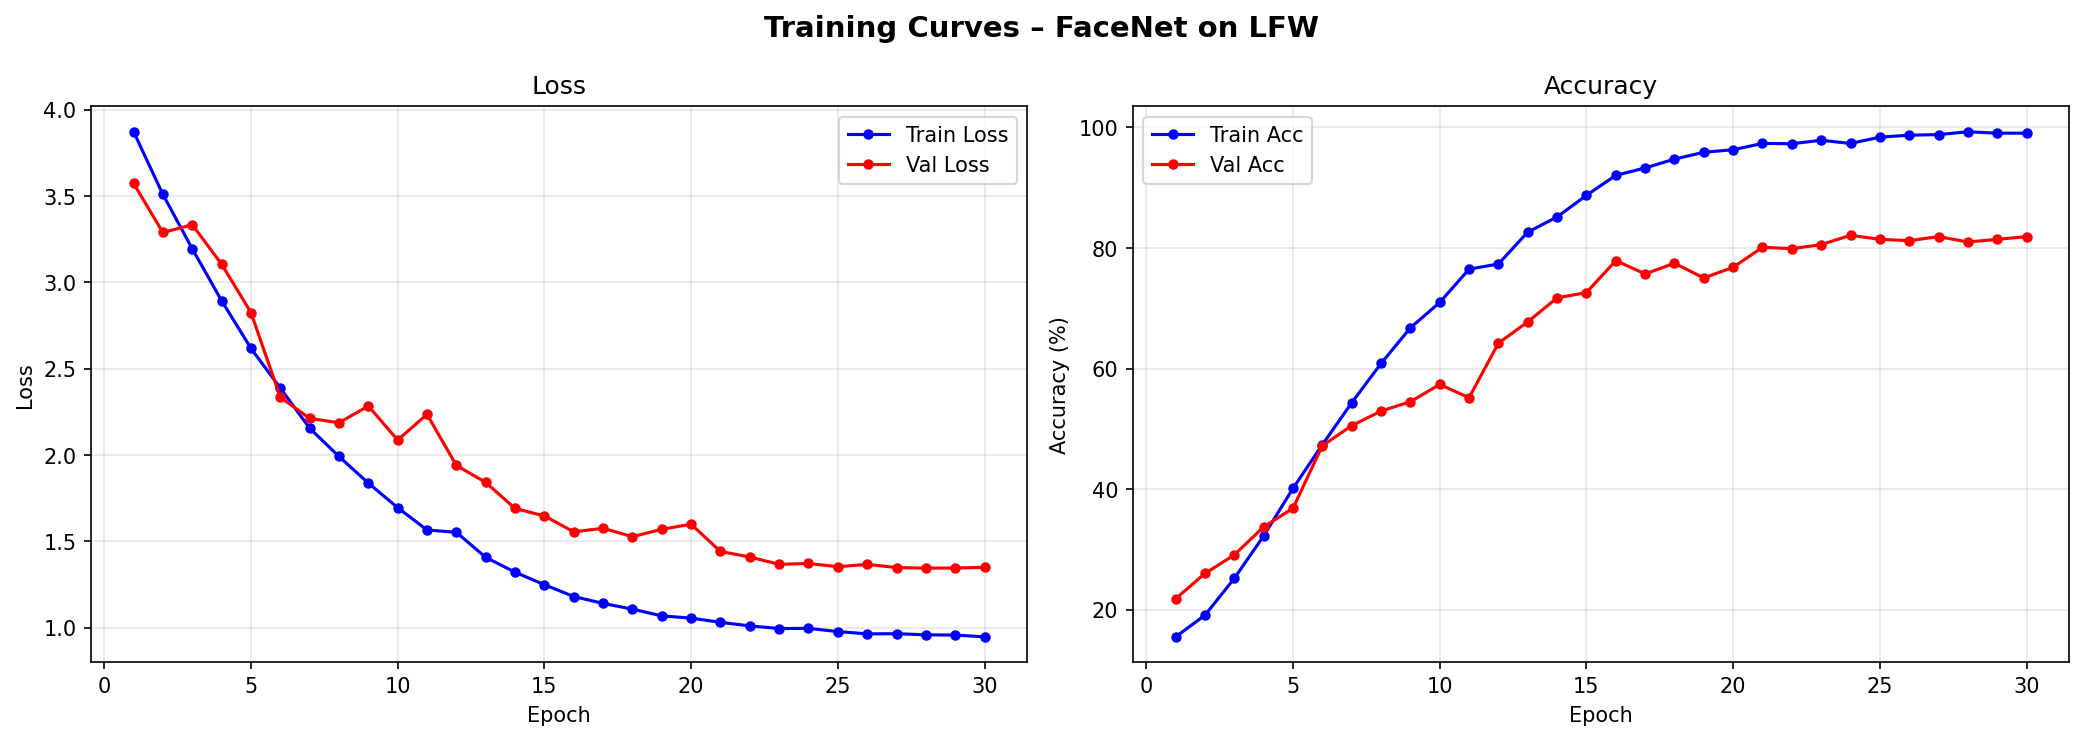

In [ ]:
plot_training_curves(history)
from IPython.display import Image as DisplayImage, display
display(DisplayImage(filename=CFG.out_dir / "training_curves.png"))

In [ ]:
#Metrices
def plot_confusion_matrix(y_true, y_pred, class_names, top_n=15):
    """Plot confusion matrix for the top-N most frequent classes."""
    from collections import Counter
    counts   = Counter(y_true)
    top_ids  = [c for c, _ in counts.most_common(top_n)]
    top_names = [class_names[i] for i in top_ids]

    mask_t = np.isin(y_true, top_ids)
    yt = np.array(y_true)[mask_t]
    yp = np.array(y_pred)[mask_t]

    # re-map to 0..top_n-1
    remap = {old: new for new, old in enumerate(top_ids)}
    yt = np.array([remap[v] for v in yt])
    yp = np.array([remap.get(v, -1) for v in yp])
    valid = yp >= 0
    yt, yp = yt[valid], yp[valid]

    cm = confusion_matrix(yt, yp, labels=list(range(len(top_ids))))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=top_names, yticklabels=top_names, ax=ax,
                linewidths=0.5, vmin=0, vmax=1)
    ax.set_title(f"Normalised Confusion Matrix – Top {top_n} Identities",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    path = CFG.out_dir / "confusion_matrix.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"[SAVED] {path}")


def report_metrics(y_true, y_pred, class_names):
    acc  = accuracy_score(y_true, y_pred)
    f1_w = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    f1_m = f1_score(y_true, y_pred, average="macro",    zero_division=0)

    print("\n" + "═"*50)
    print("  TEST SET METRICS")
    print("═"*50)
    print(f"  Accuracy         : {acc:.4f} ({acc:.2%})")
    print(f"  Weighted F1      : {f1_w:.4f}")
    print(f"  Macro F1         : {f1_m:.4f}")
    print("═"*50)

    # Per-class report (top 20 classes by support)
    from collections import Counter
    top20 = [c for c, _ in Counter(y_true).most_common(20)]
    mask  = np.isin(y_true, top20)
    yt20  = np.array(y_true)[mask]
    yp20  = np.array(y_pred)[mask]
    names20 = [class_names[i] for i in sorted(set(yt20))]

    print("\n  Per-class report (top 20 identities by support):\n")
    print(classification_report(yt20, yp20,
                                labels=sorted(set(yt20)),
                                target_names=names20,
                                zero_division=0))



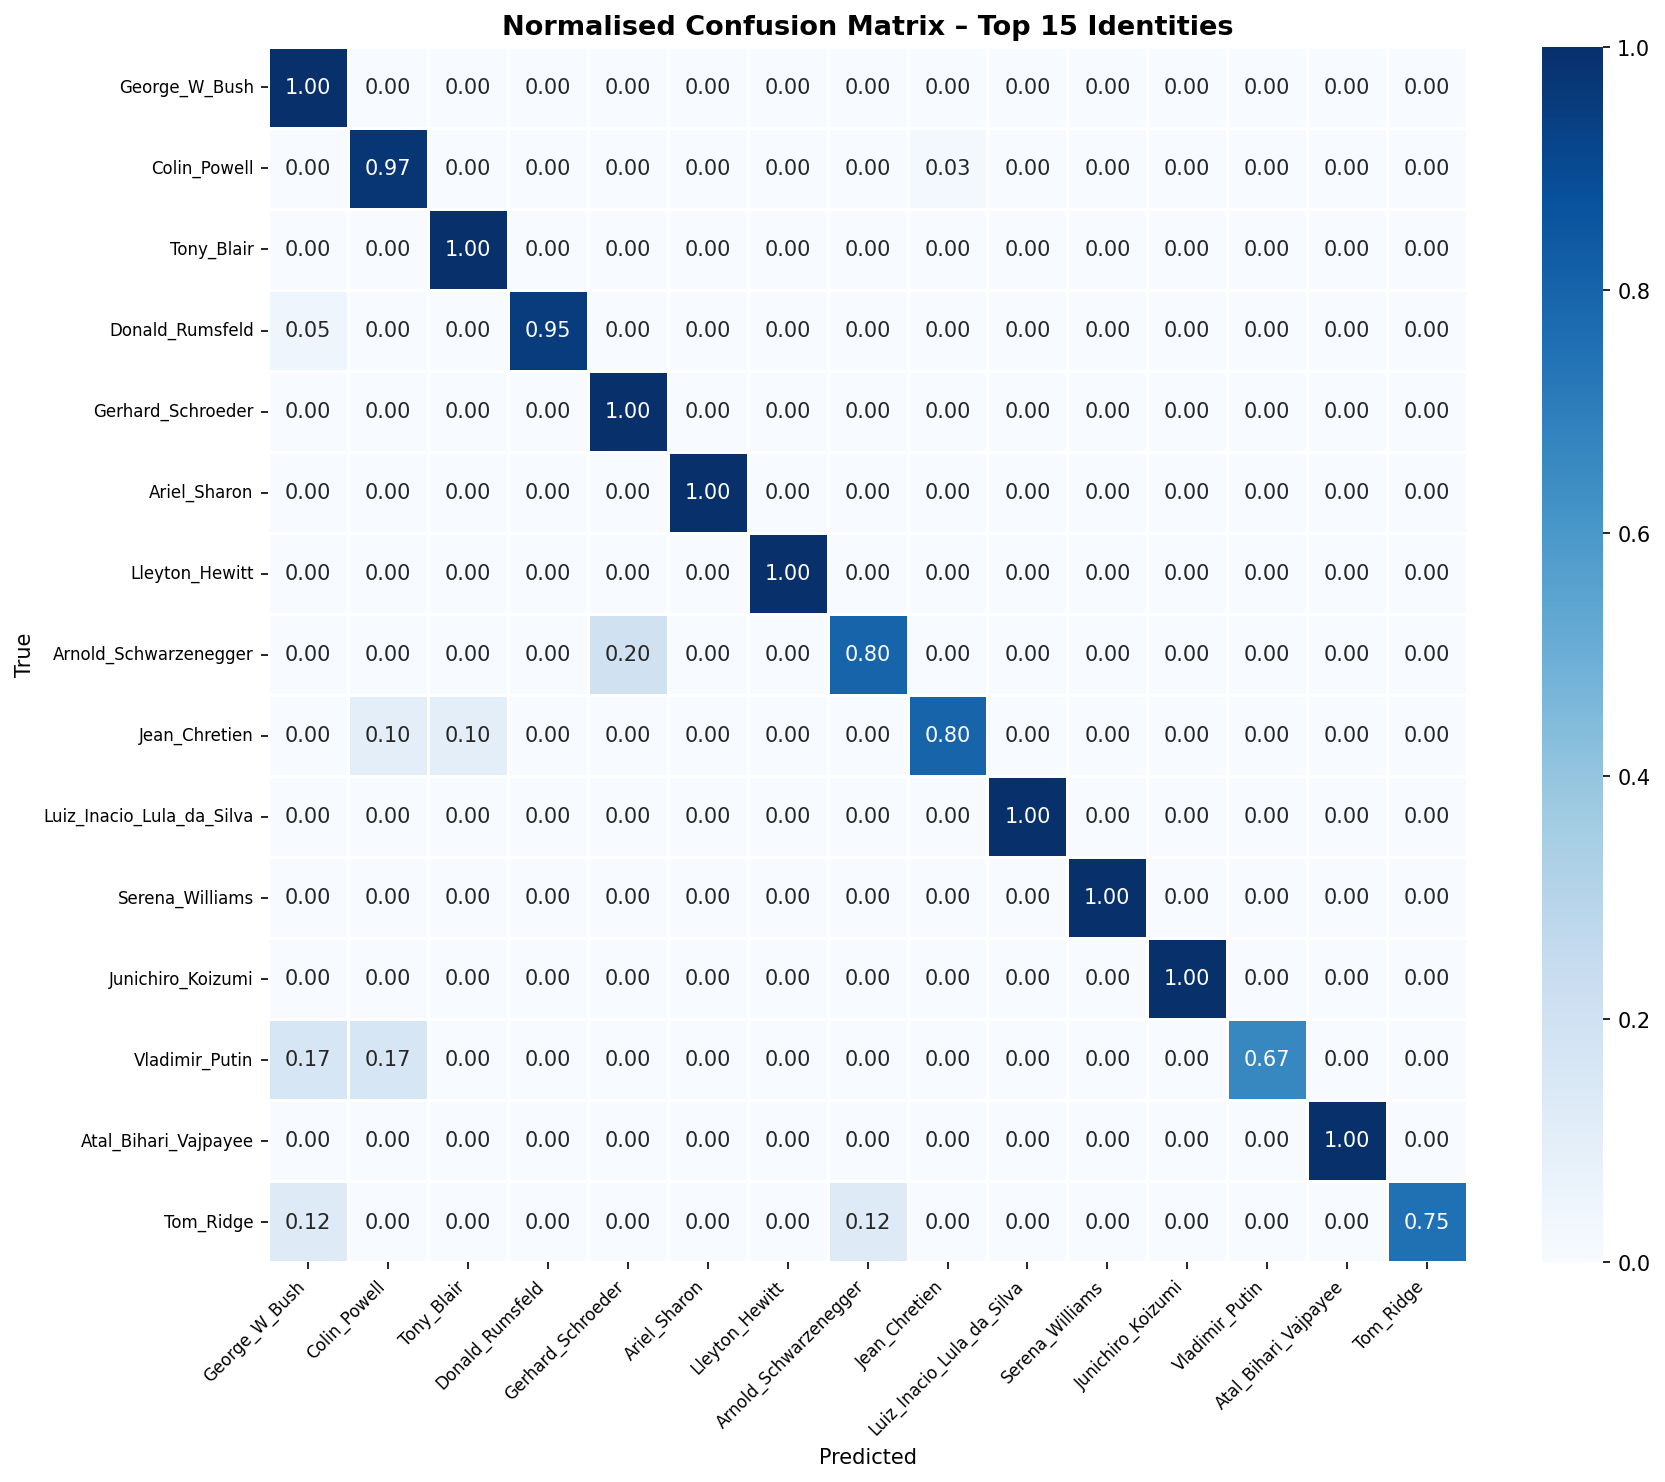

In [ ]:

display(Image(filename=CFG.out_dir / "confusion_matrix.png"))

In [ ]:
#Checking sample
def plot_prediction_grid(model, test_ds, class_names, n=16):
    model.eval()
    indices = random.sample(range(len(test_ds)), n)
    side    = int(np.ceil(np.sqrt(n)))

    fig, axes = plt.subplots(side, side, figsize=(side * 2.5, side * 2.8))
    fig.suptitle("Sample Predictions on Test Set", fontsize=13, fontweight="bold")

    for k, idx in enumerate(indices):
        ax = axes[k // side][k % side]
        img_t, lbl = test_ds[idx]
        with torch.no_grad():
            pred = model(img_t.unsqueeze(0).to(DEVICE)).argmax(1).item()
        img_np = denorm(img_t)
        ax.imshow(img_np)
        ax.axis("off")
        c = "green" if pred == lbl else "red"
        ax.set_title(f"P:{class_names[pred][:10]}\nT:{class_names[lbl][:10]}",
                     fontsize=6, color=c)

    # hide unused axes
    for k in range(len(indices), side * side):
        axes[k // side][k % side].axis("off")

    plt.tight_layout()
    path = CFG.out_dir / "prediction_grid.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"[SAVED] {path}")

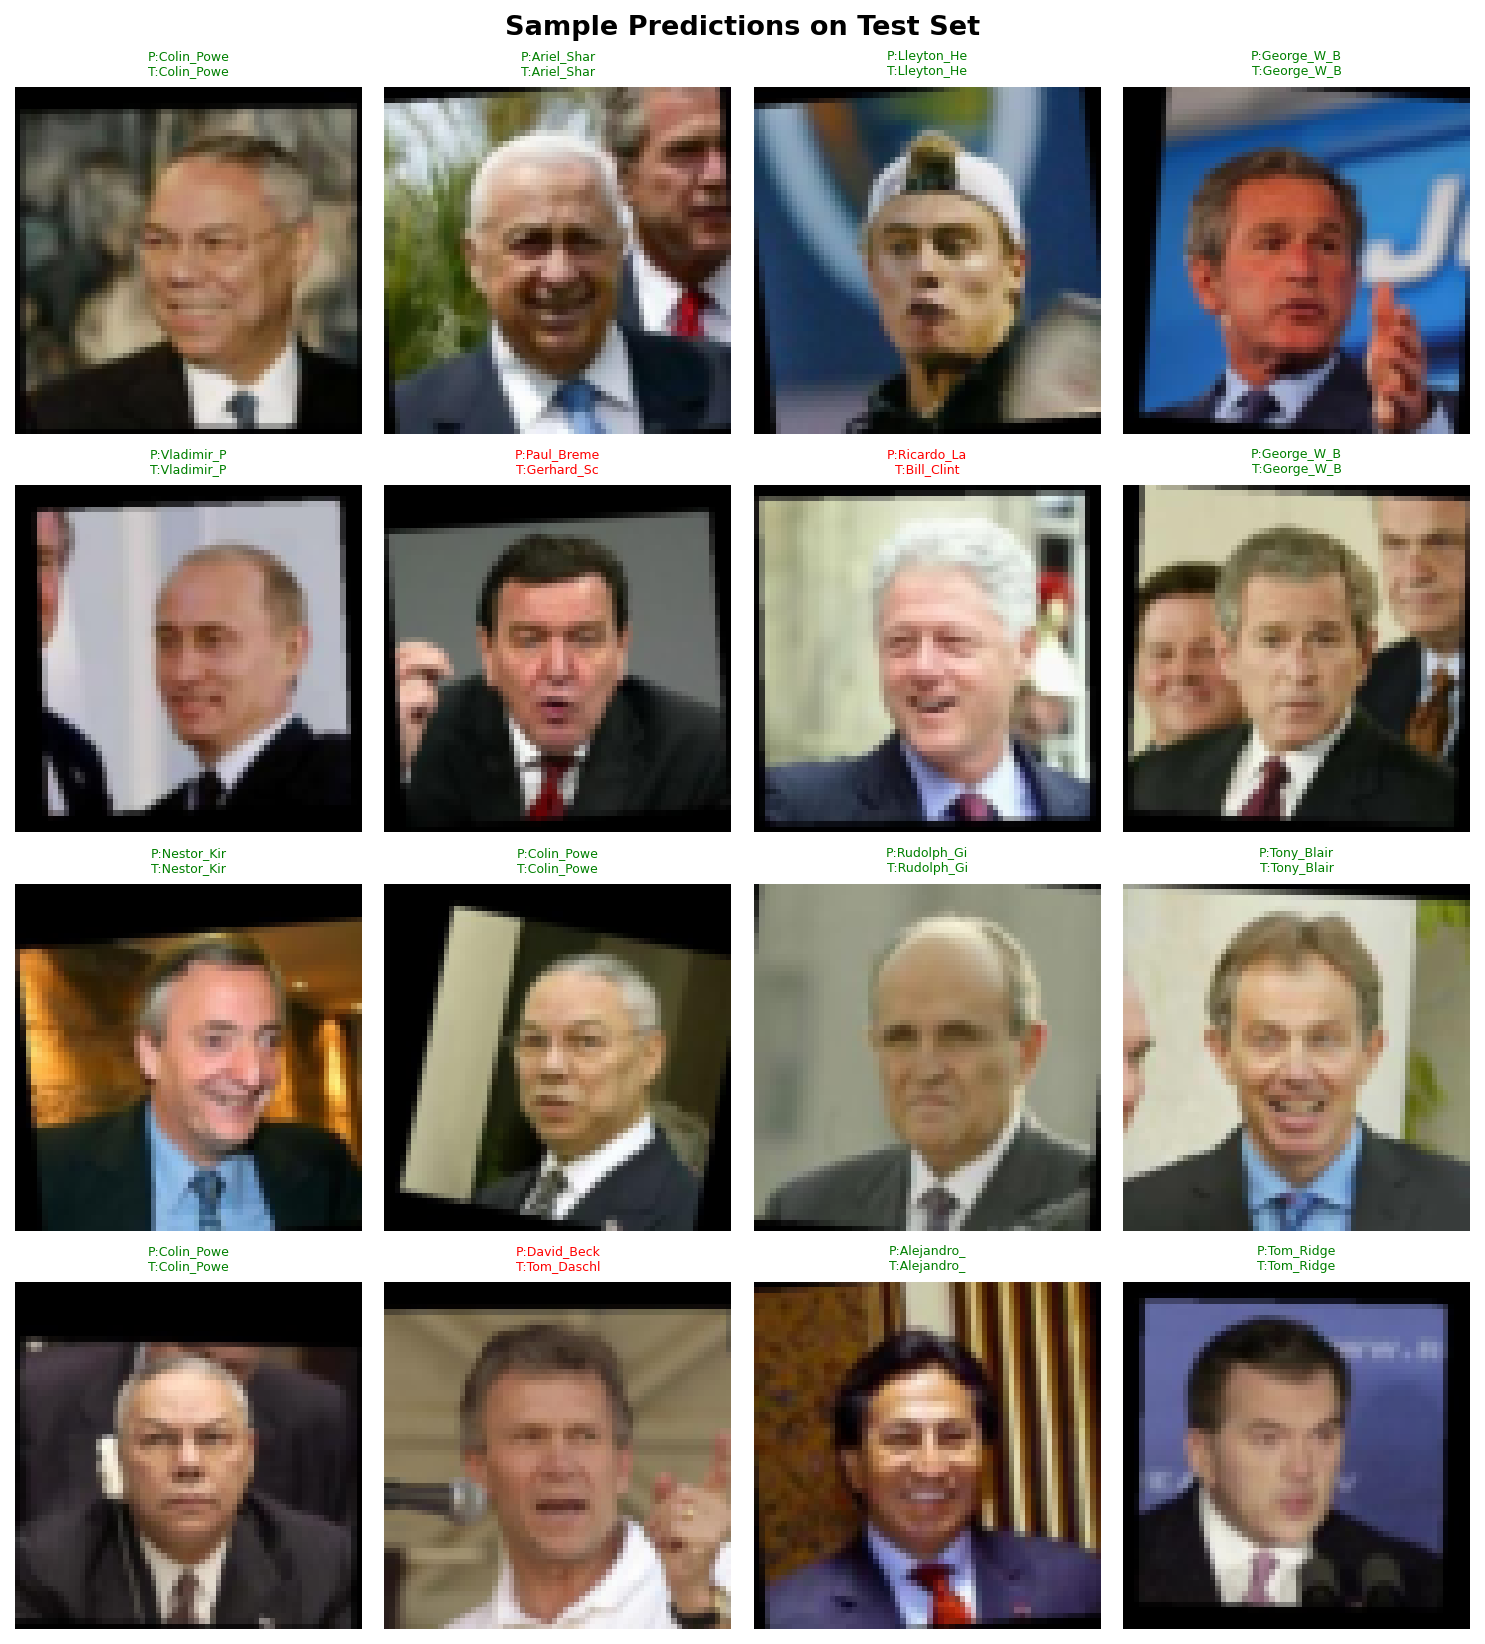

In [ ]:

from IPython.display import Image as DisplayImage
display(DisplayImage(filename=CFG.out_dir / "prediction_grid.png"))

In [ ]:

class GradCAM:

    def __init__(self, model: FaceNet):
        self.model       = model
        self._features   = None
        self._gradients  = None

        # hook onto model.last_conv[-1]  (the final ReLU after last Conv)
        target_layer = model.last_conv[-1]   # ReLU
        target_layer.register_forward_hook(self._save_features)
        target_layer.register_full_backward_hook(self._save_gradients)

    def _save_features(self, module, inp, out):
        self._features = out.detach()

    def _save_gradients(self, module, grad_in, grad_out):
        self._gradients = grad_out[0].detach()

    def generate(self, img_tensor: torch.Tensor, target_class: int = None):
        """
        img_tensor : (1, 3, H, W) on DEVICE
        Returns    : cam (numpy H×W, values 0-1),  pred_class (int)
        """
        self.model.eval()
        img_tensor = img_tensor.to(DEVICE).requires_grad_(False)

        logits = self.model(img_tensor)
        pred   = logits.argmax(dim=1).item()
        cls    = target_class if target_class is not None else pred

        self.model.zero_grad()
        score = logits[0, cls]
        score.backward()

        # global-average-pool the gradients → channel weights
        weights = self._gradients.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
        cam     = (weights * self._features).sum(dim=1, keepdim=True)
        cam     = F.relu(cam)

        # upsample to input size
        cam = F.interpolate(cam, size=(CFG.img_size, CFG.img_size),
                            mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, pred


def denorm(t):
    """Reverse normalisation for display."""
    t = t * 0.5 + 0.5          # [-1,1] → [0,1]
    return t.clamp(0, 1).permute(1, 2, 0).cpu().numpy()


def overlay_cam(img_np, cam, alpha=0.45):
    """Blend heat-map onto image."""
    h, w = img_np.shape[:2]
    cmap   = plt.get_cmap("jet")
    heat   = cmap(cam)[..., :3]       # (H, W, 3)
    overlay = (1 - alpha) * img_np + alpha * heat
    return overlay.clip(0, 1)


def show_gradcam_results(model, test_ds, class_names, n_samples=6):
    """
    Generate, display, and save Grad-CAM visualisations.
    Call this directly after training:
        show_gradcam_results(model, test_ds, class_names, n_samples=6)
    """
    gradcam = GradCAM(model)
    model.eval()

    # pick random samples
    indices = random.sample(range(len(test_ds)), n_samples)

    cols = 3   # original | heatmap | overlay
    rows = n_samples
    fig = plt.figure(figsize=(cols * 4, rows * 3.5))
    fig.suptitle("Grad-CAM Visualisations – LFW Face Recognition",
                 fontsize=14, fontweight="bold", y=1.01)

    for row, idx in enumerate(indices):
        img_tensor, true_label = test_ds[idx]
        inp = img_tensor.unsqueeze(0)

        cam, pred = gradcam.generate(inp)
        img_np = denorm(img_tensor)
        heat_over = overlay_cam(img_np, cam)

        true_name = class_names[true_label]
        pred_name = class_names[pred]
        correct = "✓" if pred == true_label else "✗"
        colour = "green" if pred == true_label else "red"

        print(f"Sample {row+1}: True = {true_name}, Predicted = {pred_name}")

        for col, data in enumerate([
            img_np,
            plt.get_cmap("jet")(cam)[..., :3],
            heat_over
        ]):
            ax = fig.add_subplot(rows, cols, row * cols + col + 1)
            ax.imshow(data)
            ax.axis("off")

            if col == 0:
                ax.set_title(f"True: {true_name}", fontsize=8, pad=2)
            elif col == 1:
                ax.set_title("Heat Map", fontsize=8, pad=2)
            else:
                ax.set_title(f"{correct} Pred: {pred_name}",
                             fontsize=8, pad=2, color=colour)

    plt.tight_layout()
    path = CFG.out_dir / "gradcam_visualisations.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"\n[SAVED] {path}")


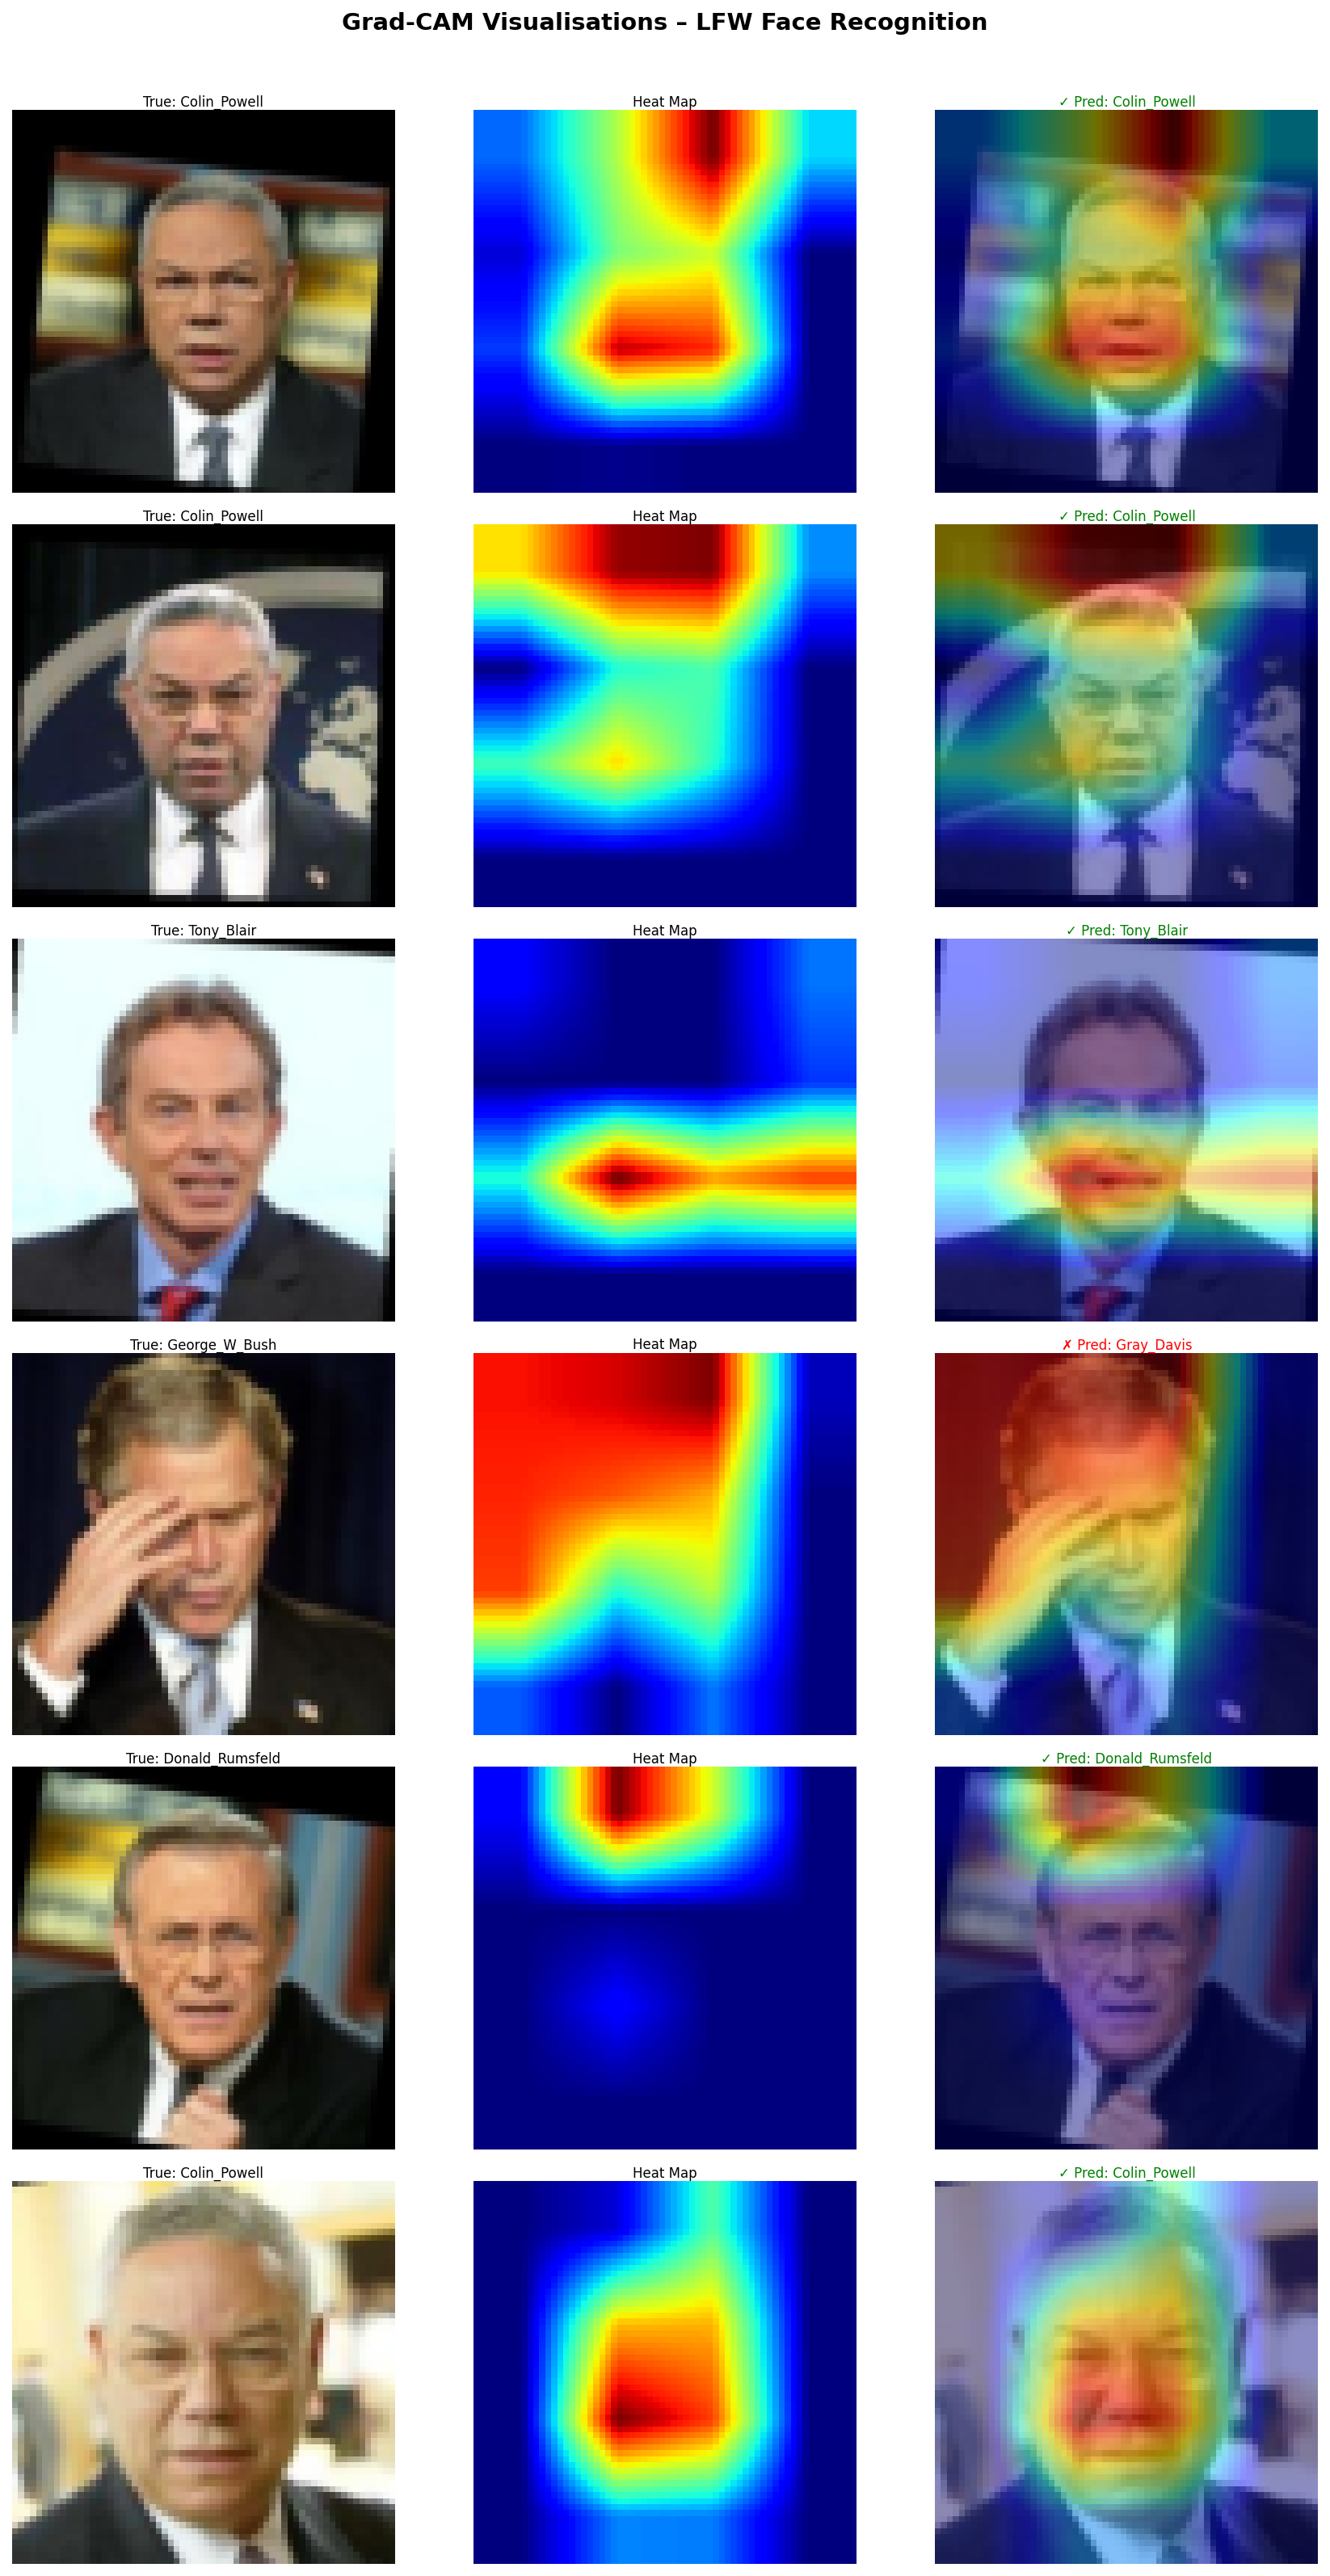

In [ ]:

from IPython.display import Image as DisplayImage
display(DisplayImage(filename=CFG.out_dir / "gradcam_visualisations.png"))

In [ ]:
#Calling the main function
def main():
    # ── sanity check ──────────────────────────────────────────────────────
    if DATASET_ROOT == "/content/drive/MyDrive/lfw-deepfunneled":
        print("="*60)
        print("  ⚠  DATASET_ROOT is not set.")
        print("  Please edit the DATASET_ROOT variable at the top of")
        print("  this file to point to your LFW dataset folder.")
        print("="*60)


    # ── data ──────────────────────────────────────────────────────────────
    train_loader, val_loader, test_loader, class_names, test_ds = \
        build_dataloaders()
    n_classes = len(class_names)

    # ── model ─────────────────────────────────────────────────────────────
    model = FaceNet(n_classes).to(DEVICE)
    print_model_summary(model, n_classes)

    # ── train ─────────────────────────────────────────────────────────────
    print("\n[PHASE] Training …\n")
    history = train(model, train_loader, val_loader, CFG.num_epochs)

    # ── plot curves ───────────────────────────────────────────────────────
    plot_training_curves(history)

    # ── evaluate on test set ──────────────────────────────────────────────
    print("\n[PHASE] Evaluating on test set …")
    criterion = nn.CrossEntropyLoss()
    _, _, y_pred, y_true = evaluate(model, test_loader, criterion)

    report_metrics(y_true, y_pred, class_names)
    plot_confusion_matrix(y_true, y_pred, class_names, top_n=15)
    plot_prediction_grid(model, test_ds, class_names, n=16)

    # ── Grad-CAM ──────────────────────────────────────────────────────────
    print("\n[PHASE] Generating Grad-CAM visualisations …")
    plot_gradcam(model, test_ds, class_names, n_samples=6)

    print("\n[DONE] All outputs saved to:", CFG.out_dir.resolve())
    print("       ├── best_facenet.pth")
    print("       ├── training_curves.png")
    print("       ├── confusion_matrix.png")
    print("       ├── prediction_grid.png")
    print("       └── gradcam_visualisations.png\n")


if __name__ == "__main__":
    main()

  ⚠  DATASET_ROOT is not set.
  Please edit the DATASET_ROOT variable at the top of
  this file to point to your LFW dataset folder.
[INFO] LFW root found at: /content/drive/MyDrive/lfw-deepfunneled

[INFO] Classes (identities) : 62
[INFO] Total images          : 3023
[INFO] Train / Val / Test    : 2116 / 453 / 454

──────────────────────────────────────────────────
  Model          : FaceNet
  Classes        : 62
  Total params   : 1,143,646
  Trainable      : 1,143,646
──────────────────────────────────────────────────


[PHASE] Training …

 Epoch   Tr Loss   Tr Acc   Val Loss   Val Acc          LR
────────────────────────────────────────────────────────────
     1    3.9300  14.13%     3.6201   17.22%    9.97e-04  (12.9s)
     2    3.6105  17.16%     3.3252   25.17%    9.89e-04  (12.8s)
     3    3.2662  23.06%     3.4981   23.84%    9.76e-04  (13.4s)
     4    2.9587  30.15%     2.9876   34.66%    9.57e-04  (13.7s)
     5    2.7424  38.09%     2.9583   34.22%    9.33e-04  (13.2s)
 